### Time to get your hands dirty. SDSS Galaxies vs quasars

We're now going to classify galaxy vs quasars in the Sloan Digital Sky Survey. 

This is one of the most famous example of machine-learning classification in astronomy. For some recent work see e.g. 
- *Identifying galaxies, quasars, and stars with machine learning: A new catalogue of classifications for 111 million SDSS sources without spectra* Clarke et al (2019) [arXiv:1909.10963](https://arxiv.org/abs/1909.10963)
- *Quasar and galaxy classification in Gaia Data Release 2* Bailer-Jones et al (2019) [arXiv:1910.05255](https://arxiv.org/abs/1910.05255)

Some figures from the second paper:


![Screen%20Shot%202022-02-08%20at%2014.16.28.png](attachment:Screen%20Shot%202022-02-08%20at%2014.16.28.png)

![Screen%20Shot%202022-02-08%20at%2014.16.52.png](attachment:Screen%20Shot%202022-02-08%20at%2014.16.52.png)

SDSS observed in four bands:
    
![](https://speclite.readthedocs.io/en/latest/_images/sdss2010.png) 
    

#### Data

The dataset is at `solutions/galaxyquasar.csv`. I have extracted it myself from the SDSS database using the SQL query reported [here](https://www.astroml.org/_modules/astroML/datasets/sdss_galaxy_colors.html#fetch_sdss_galaxy_colors)

(If you've never used [SQL](https://en.wikipedia.org/wiki/SQL) and want to learn something new it's computing, it's very powerful)

#### Tasks

- Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 
- Classify the dataset against the target label.
- Try some of the classification methods we've seen so far and evaluate the performance using the ROC curve.
- Remember to split the dataset into training and validation...

#### Ideas
- Try using different colors (a subset of them first, than all together). Which is the most important feature?
- What are the colors that better satisfy or invalidate the "Naive" assumption of independence between the attributes?


In [93]:
import numpy as np
import corner
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from astroML.utils import completeness_contamination
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from astroML.classification import GMMBayes
from sklearn.neighbors import KNeighborsClassifier


%config InlineBackend.figure_format='retina'

### Create arrays

In [50]:
df = pd.read_csv("../solutions/galaxyquasar.csv")

df


,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [51]:
v_ug = df['u'] - df['g']
v_gr = df['g'] - df['r']
v_ri = df['r'] - df['i']
v_iz = df['i'] - df['z']

X = np.column_stack( (v_ug, v_gr, v_ri, v_iz) )
print("X shape:", X.shape)

# Create binary labels from the 'class' column of the DataFrame
labels = np.where(
    df['class'] == 'QSO',  # Condition: check if the value in the 'class' column is equal to 'QSO'
    1,                     # If the condition is True (i.e., class is 'QSO'), assign label 1
    0                      # If the condition is False (i.e., class is not 'QSO'), assign label 0
)

X shape: (50000, 4)


### Data exploration

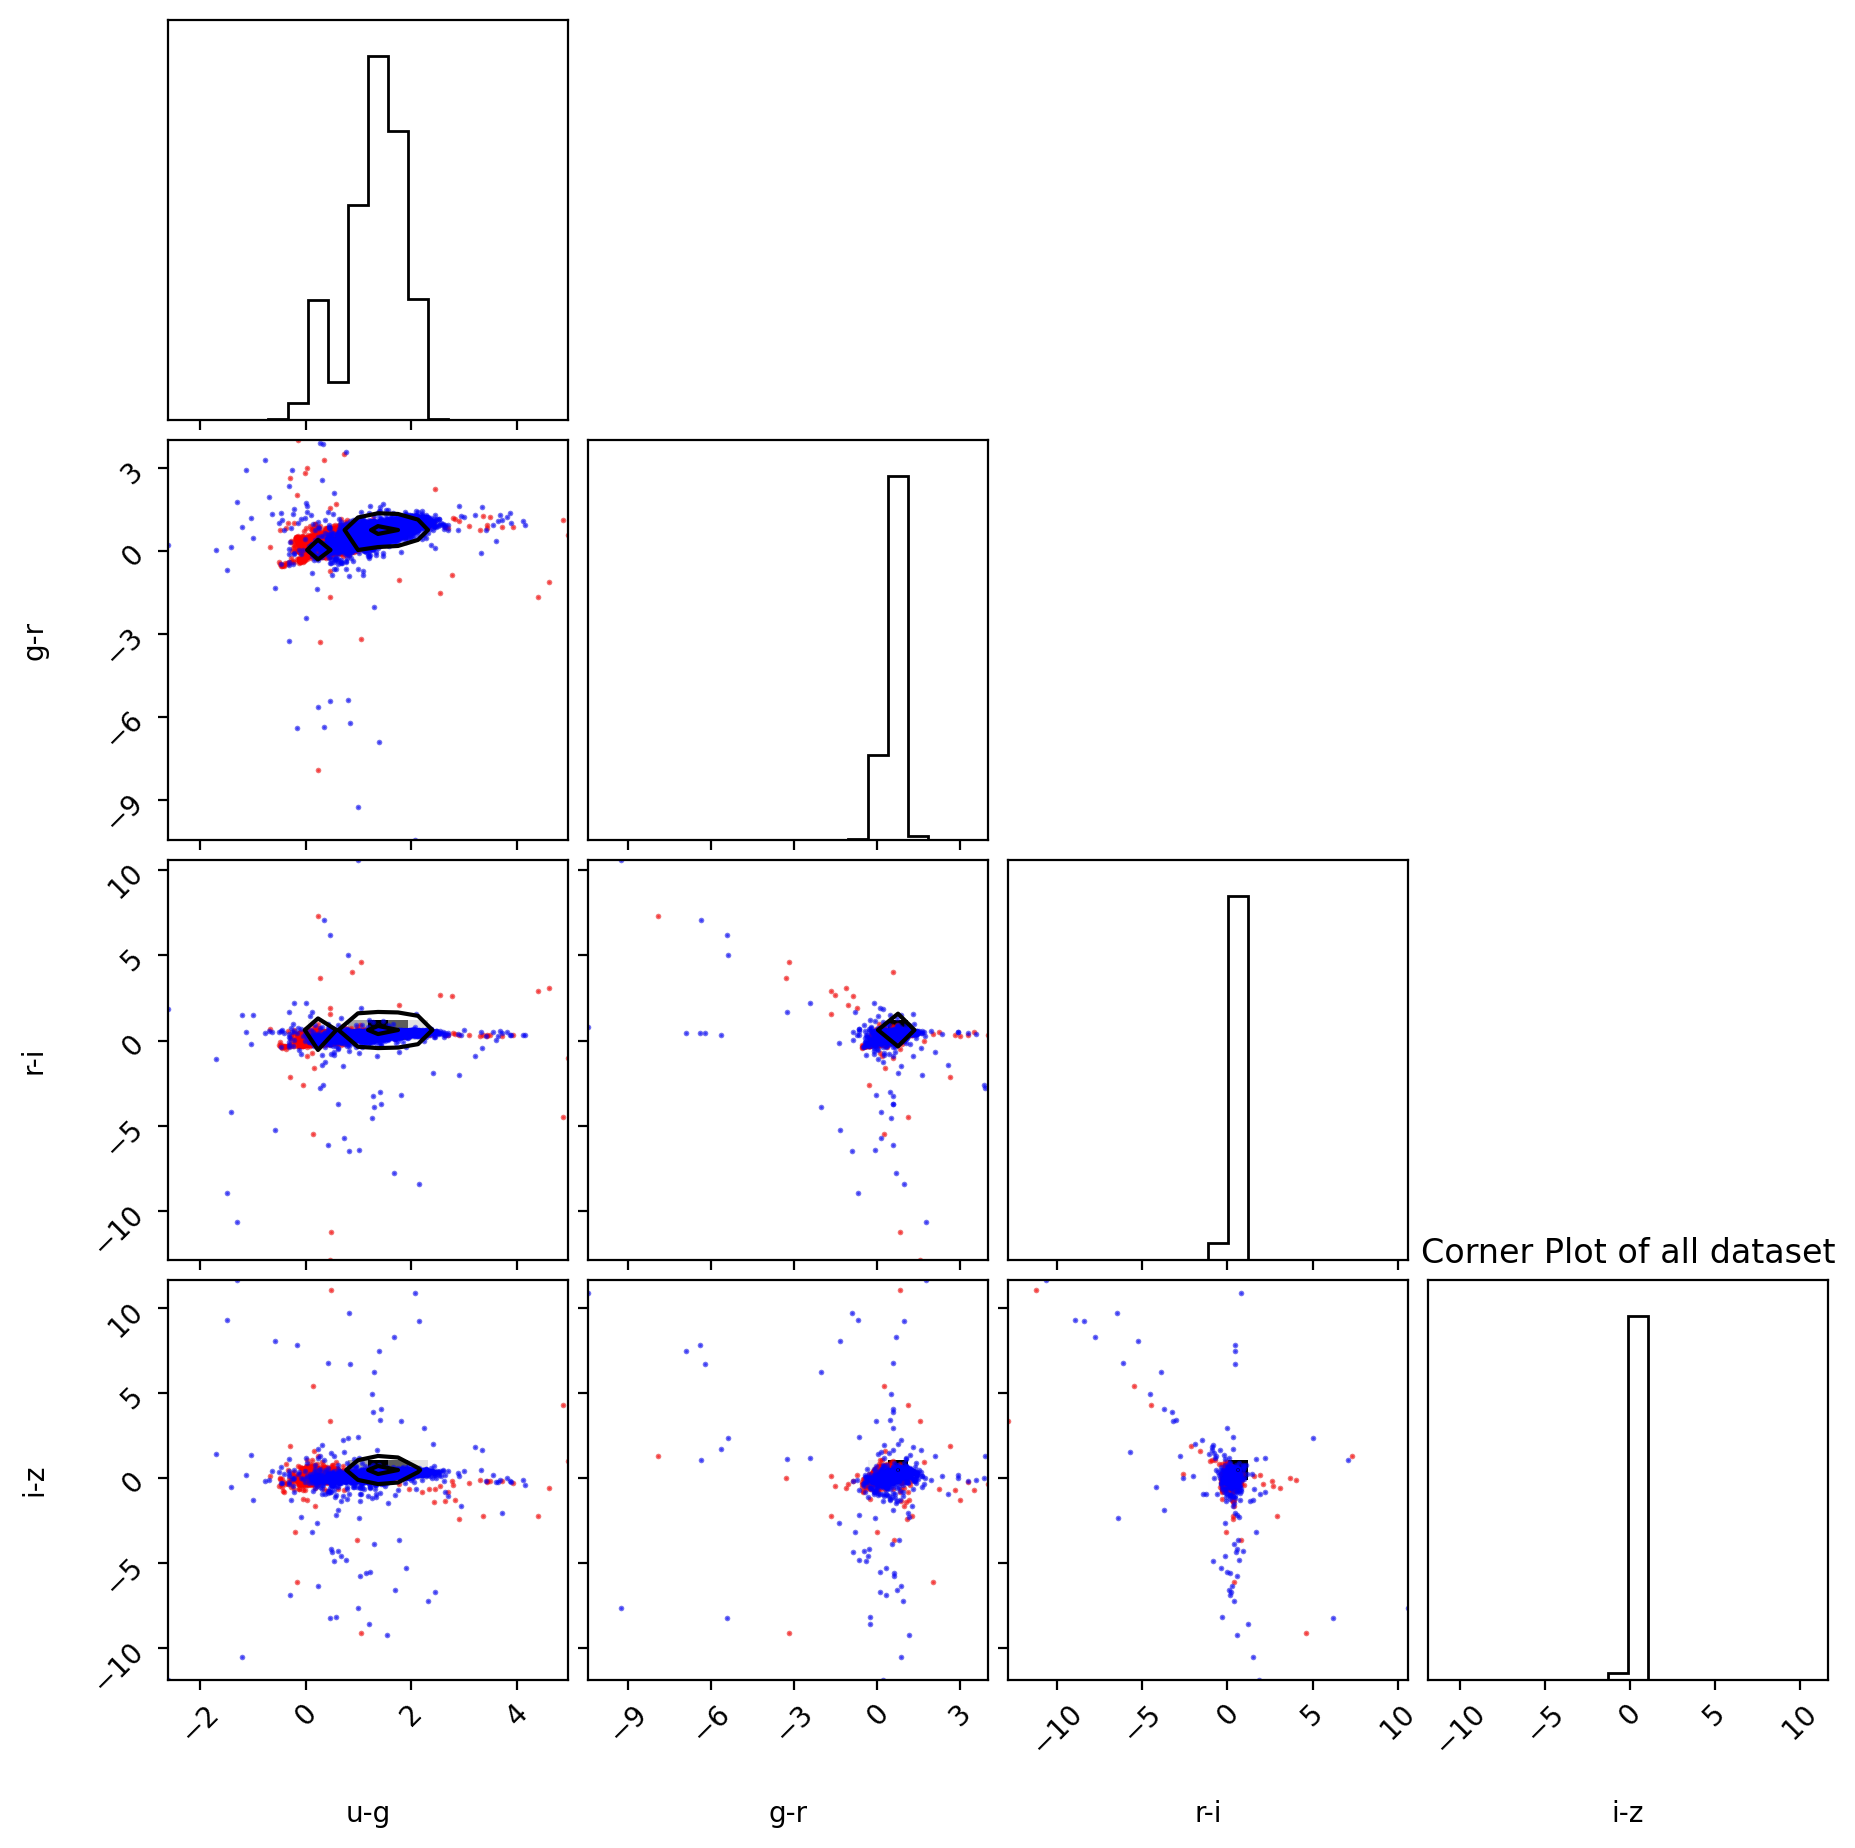

In [52]:
figure = corner.corner( X, labels=["u-g", "g-r", "r-i", "i-z"], levels=[0.68,0.95]
);

plt.title("Corner Plot of all dataset")
axes = np.array(figure.axes).reshape((4, 4))

for i in range(4):
    for j in range(i):
        ax = axes[i, j]
        ax.scatter(X[labels == 1, j], X[labels == 1, i], color="red", s=1, label="QSO", alpha=0.5)
        ax.scatter(X[labels == 0, j], X[labels == 0, i], color="blue", s=1, label="Galaxy", alpha=0.5)

plt.show()

Red Point = Quasar  
Blue Point = Galaxy

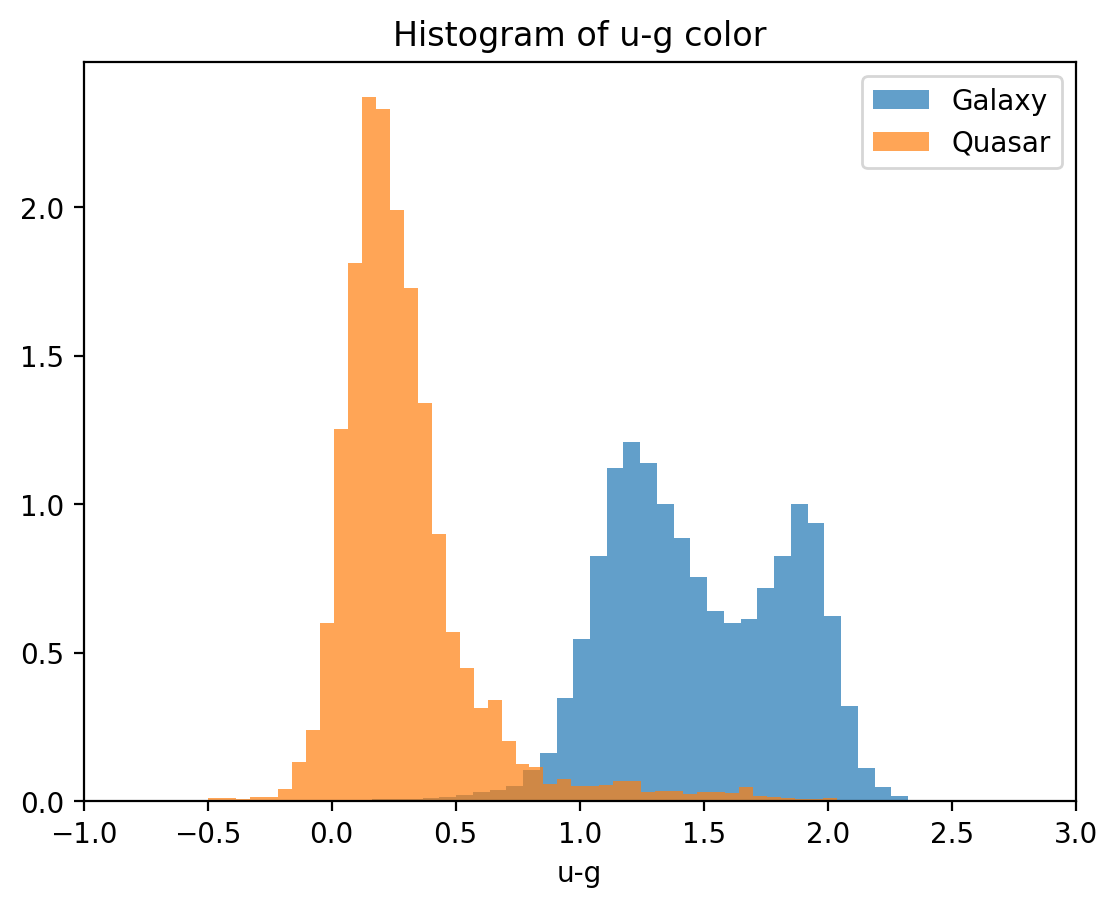

In [53]:
plt.hist(v_ug[labels==0], bins=100, density=True, alpha=0.7, label='Galaxy')
plt.hist(v_ug[labels==1], bins=100, density=True, alpha=0.7, label='Quasar')
plt.xlim(-1,3)
plt.xlabel('u-g')
plt.title("Histogram of u-g color")
plt.legend()

### Test train split

In [54]:
X_train, X_val, label_train, label_val = train_test_split(X, labels, test_size=0.3, random_state=42) # use train_test_split from sklearn to split data randomly into training and validation sets
print(X_train.shape)
print(X_val.shape)

(35000, 4)
(15000, 4)


### Gaussian Naive Bayes

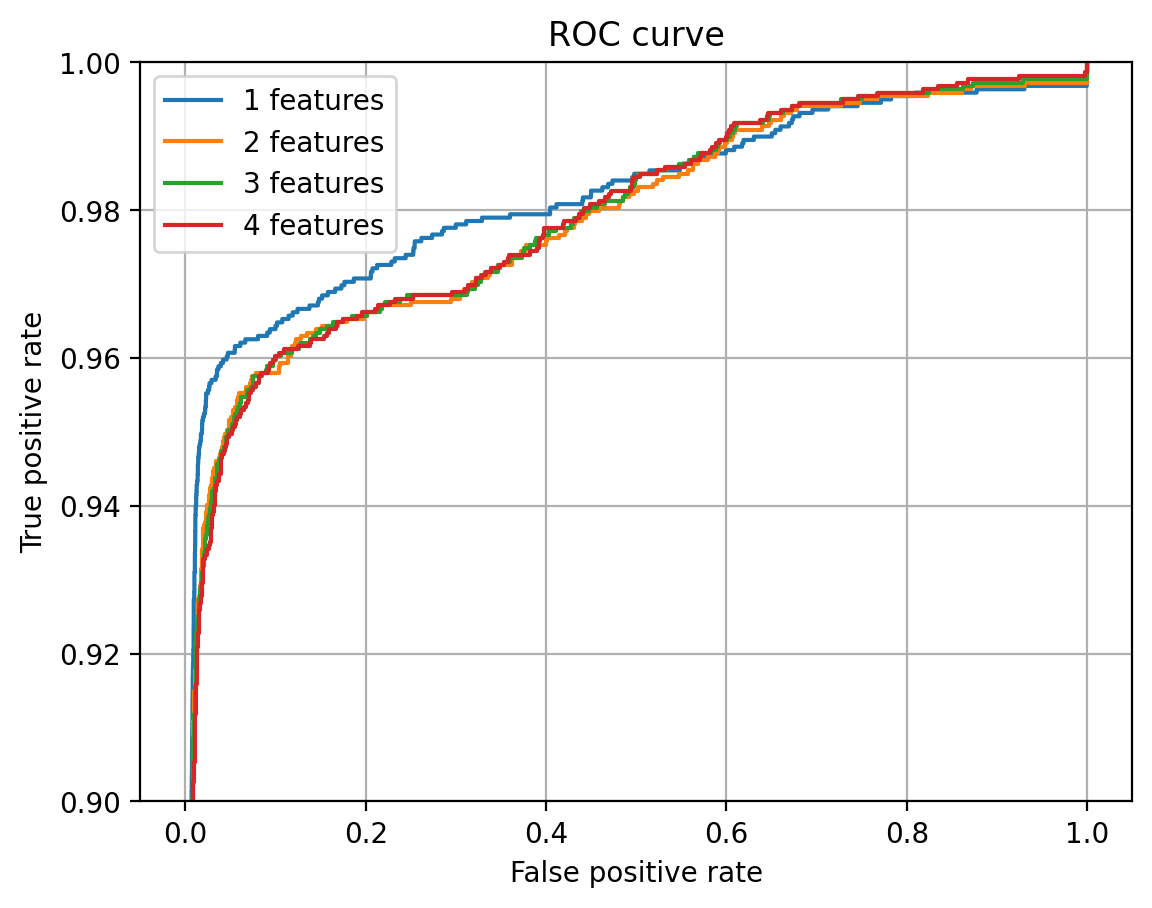

In [55]:
for i in range(4): # Every loop fit with one more component (a color)
    clf = GaussianNB()
    clf.fit(X_train[:, 0:i+1], label_train) # Classifies if it's Galaxy or a Quasar. Every loop add a component (a color)

    # Outputing the probabilities of class 1
    label_prob = clf.predict_proba(X_val[:, 0:i+1]) [:, 1]
    
    # ROC curve
    fpr, tpr, thresh = roc_curve(label_val, label_prob)
    plt.plot(fpr, tpr, label=f"{(i+1)} features")

plt.ylim(0.9, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.grid()
plt.title("ROC curve")
plt.legend()

    

The first feature (u-g) is the most important one here 

Gaussian Naive Bayes 
Completeness = [0.9309872  0.92824497 0.92687386 0.92687386] 
Contamination = [0.0591224  0.09451627 0.08730873 0.09504685]


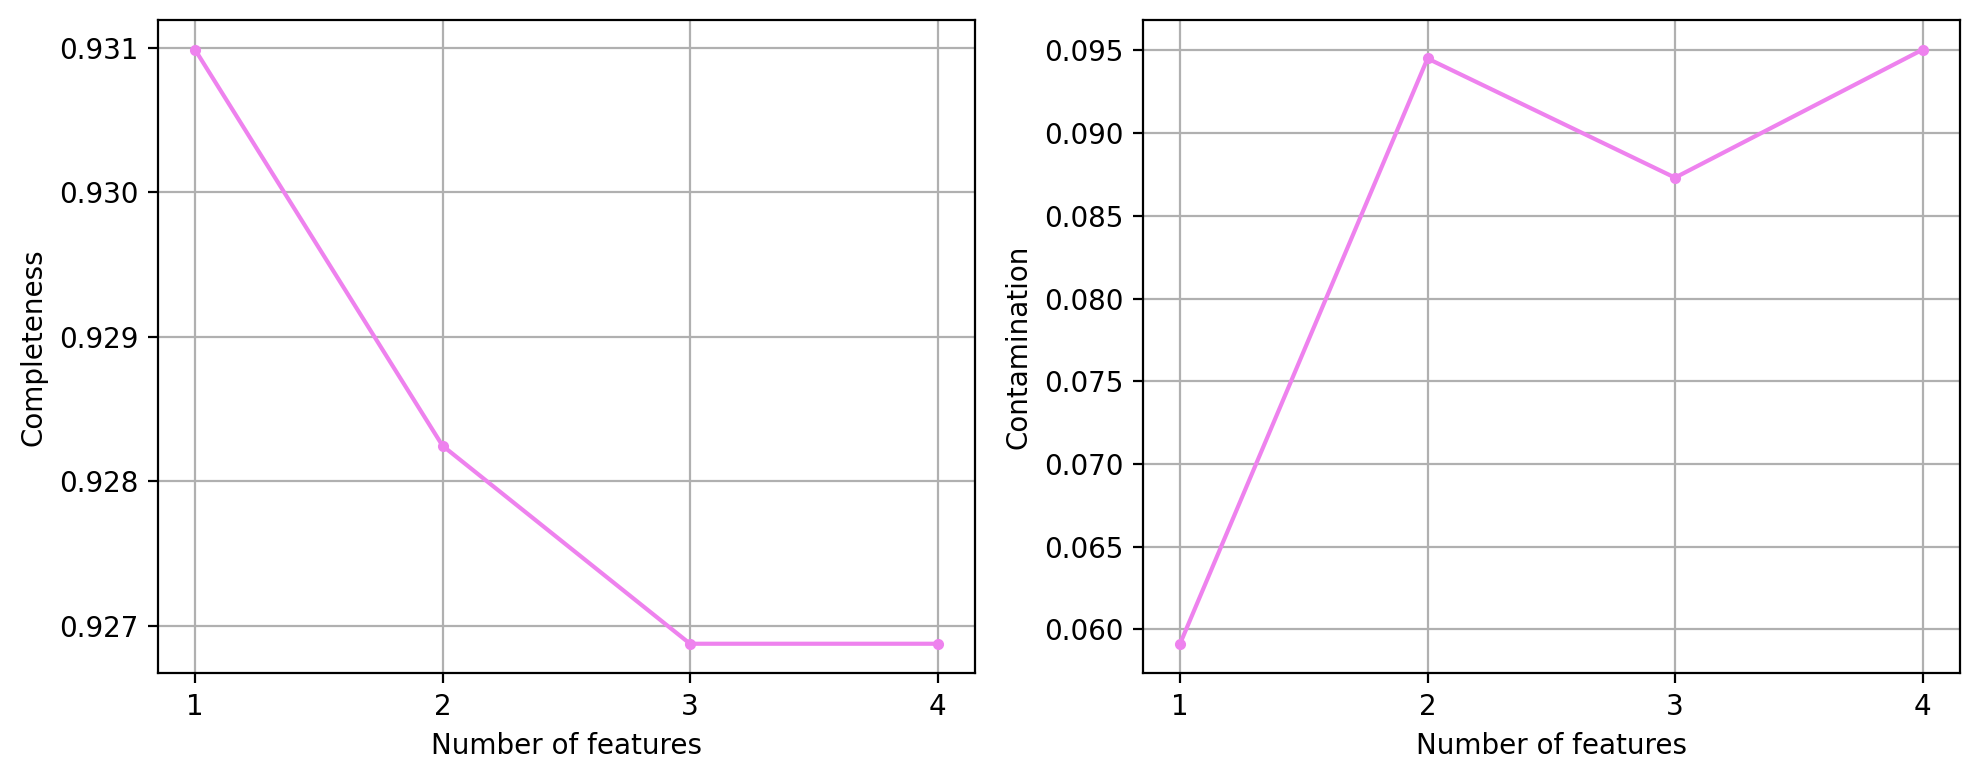

In [ ]:
feat = np.linspace(1,4,4)
lab_prob = []
lab_pred = []

for x in feat:
    
    gnb = GaussianNB(priors=None)
    gnb.fit(X_train[:,:int(x)], label_train)
    
    pred_labels = gnb.predict(X_val[:, :int(x)])
    pred_probs = gnb.predict_proba(X_val[:, :int(x)])[:, 1]
    
    lab_pred.append(pred_labels)
    lab_prob.append(pred_probs)

completeness, contamination = completeness_contamination(lab_pred, label_val)
print(f'Gaussian Naive Bayes \nCompleteness = {completeness} \nContamination = {contamination}')

# Create 2 sublpots near
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(feat, completeness, marker='.', color='violet')
axs[0].set_xlabel('Number of features')
axs[0].set_ylabel('Completeness')
axs[0].set_xticks(feat)
axs[0].grid()

axs[1].plot(feat, contamination, marker='.', color='violet')
axs[1].set_xlabel('Number of componentsures')
axs[1].set_ylabel('Contamination')
axs[1].set_xticks(components)
axs[1].grid()

plt.tight_layout()
plt.show()

Also here,t he first componentsure (u-g) is the most important one

Compare prediction with true using only u-g feauture

<function matplotlib.pyplot.show(close=None, block=None)>

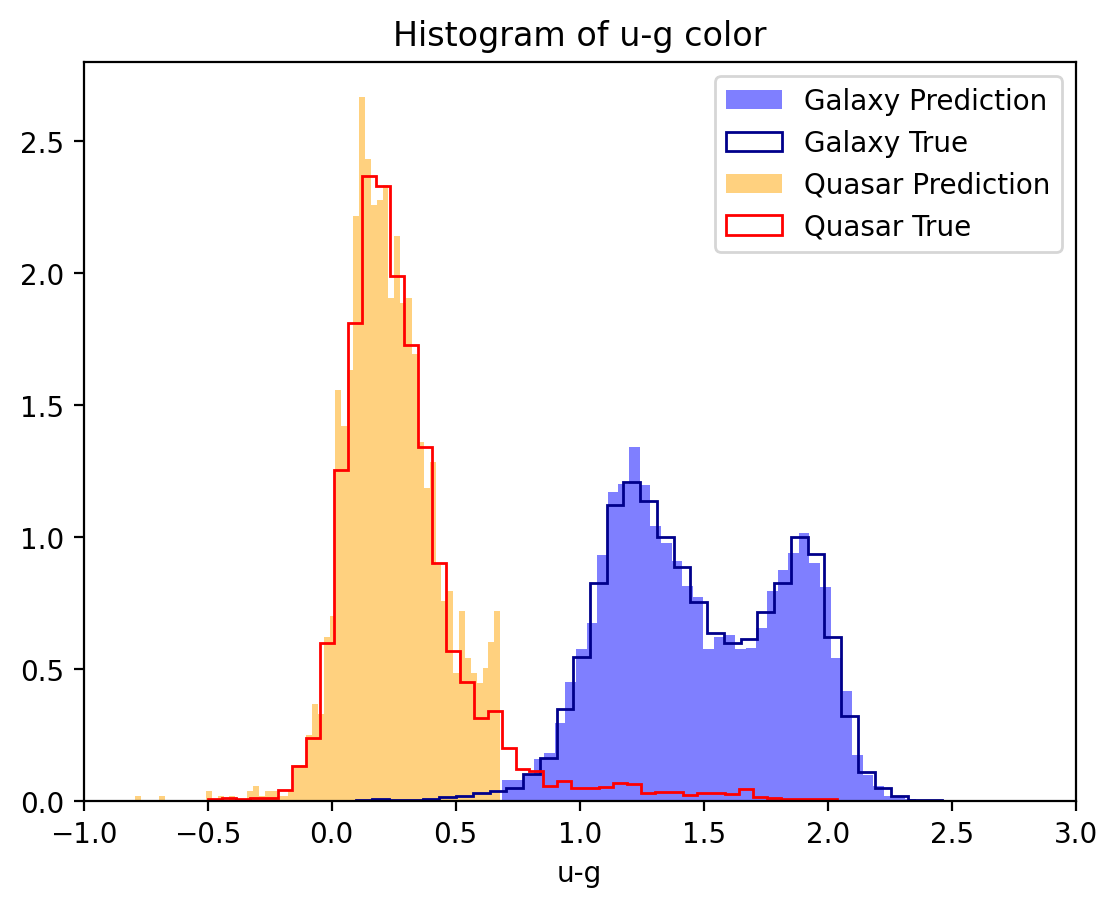

In [57]:
plt.hist( (X_val[:, 0])[ (lab_pred[0]) == 0], bins=100, density=True, alpha=0.5, color='blue', label='Galaxy Prediction')
plt.hist(v_ug[labels==0], bins=100, density=True, histtype='step', color='darkblue', label='Galaxy True')

plt.hist( (X_val[:, 0])[ (lab_pred[0]) == 1], bins=100, density=True, alpha=0.5, color='orange', label='Quasar Prediction')
plt.hist(v_ug[labels==1], bins=100, density=True, histtype='step', color='red', label='Quasar True')
#plt.hist( (X_val[:, 0])[ (lab_pred[0]) == 0], bins=100, density=True, alpha=0.7, label='Galaxy Prediction')
plt.xlim(-1,3)
plt.legend()
plt.title("Histogram of u-g color")
plt.xlabel('u-g')
plt.show

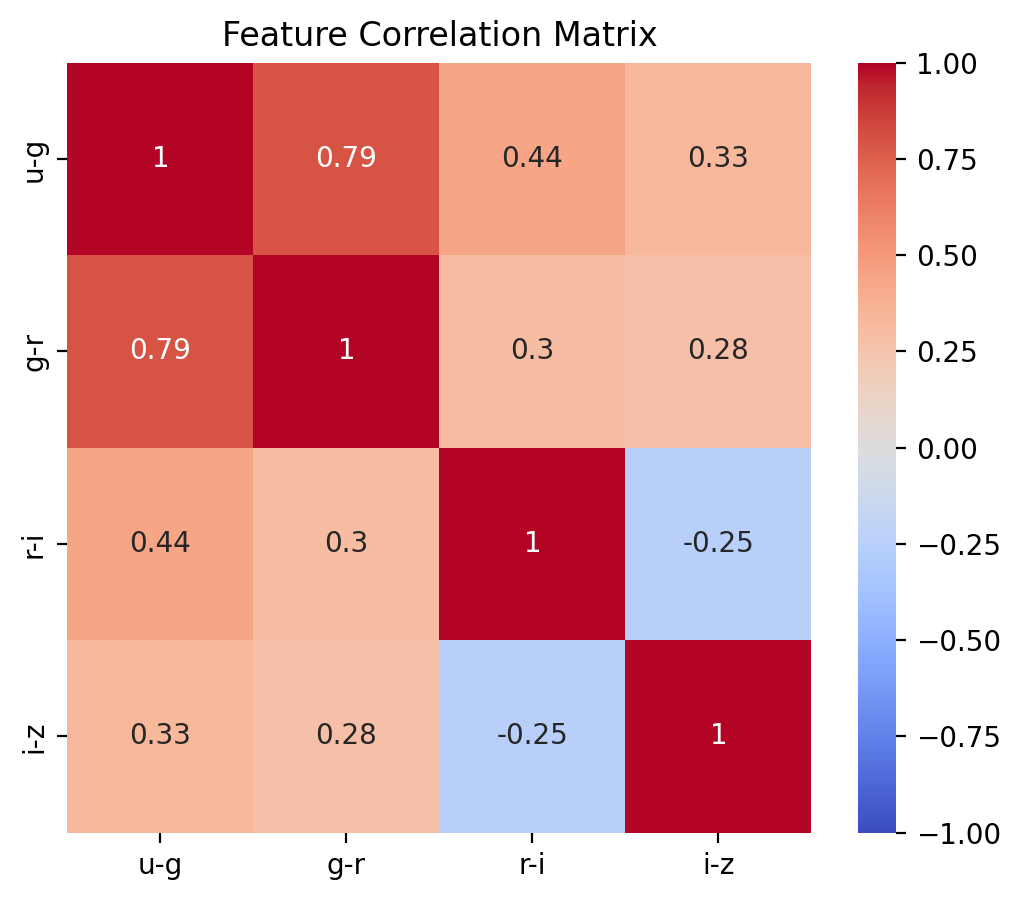

In [58]:
df = pd.DataFrame(X_train, columns=['u-g', 'g-r', 'r-i', 'i-z'])
corr_matrix = df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

Looking at the correlation matrix we can clearly see that the first and the second features are highly correlated, which is coherent with the result that we get from gaussian naive classifier that assumes all the features as independent. In fact the result is more accurate using the first feature alone rather than using it in combination with the second

### Linear Discriminant Analysis

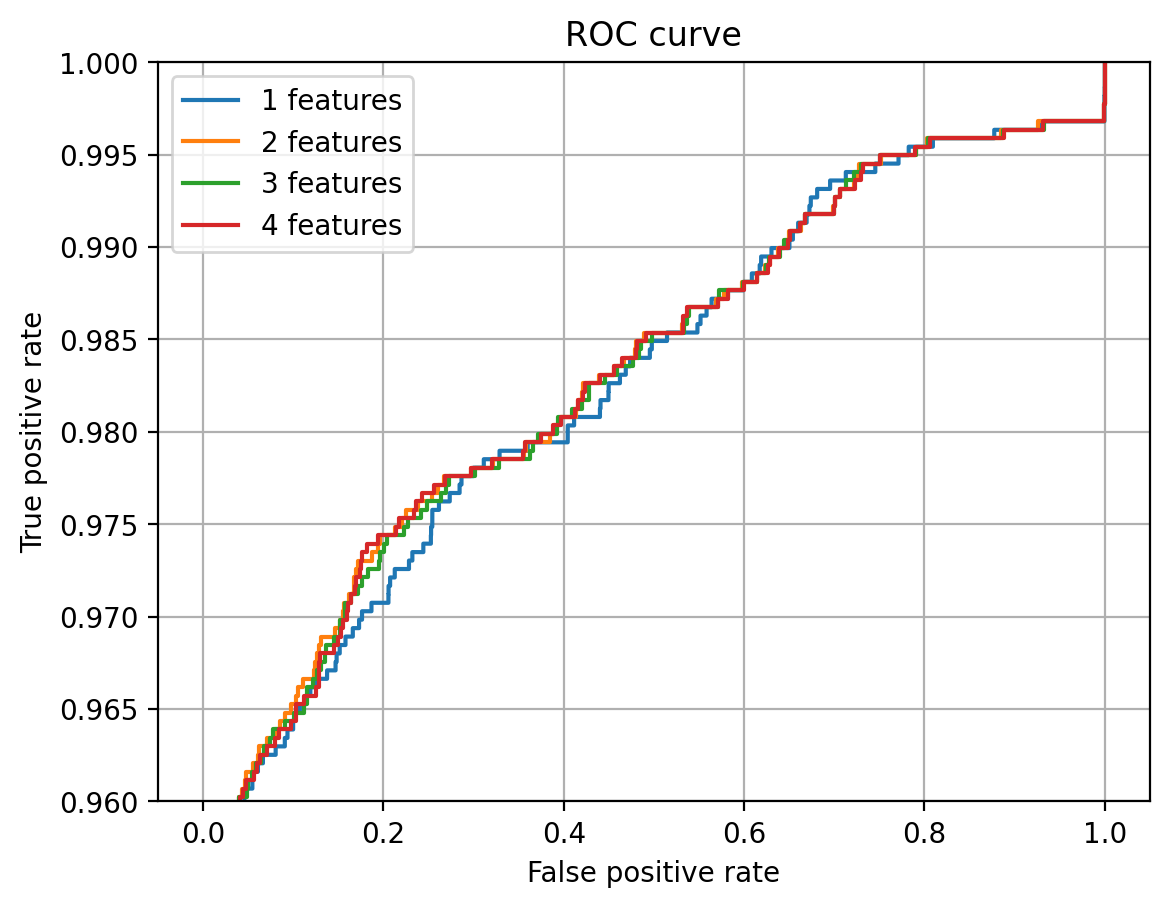

In [59]:
for i in range(4): # Every loop fit with one more component (a color)
    lda = LDA()
    lda.fit(X_train[:, 0:i+1], label_train) # Classifies if it's Galaxy or a Quasar. Every loop add a component (a color)

    # Outputing the probabilities of class 1
    label_prob = lda.predict_proba(X_val[:, 0:i+1]) [:, 1]
    
    # ROC curve
    fpr, tpr, thresh = roc_curve(label_val, label_prob)
    plt.plot(fpr, tpr, label=f"{(i+1)} features")

plt.ylim(0.96, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.grid()
plt.title("ROC curve")
plt.legend()


Completeness = [0.93327239 0.92595978 0.92687386 0.92641682] 
Contamination = [0.06201194 0.05942433 0.05849582 0.0572093 ]


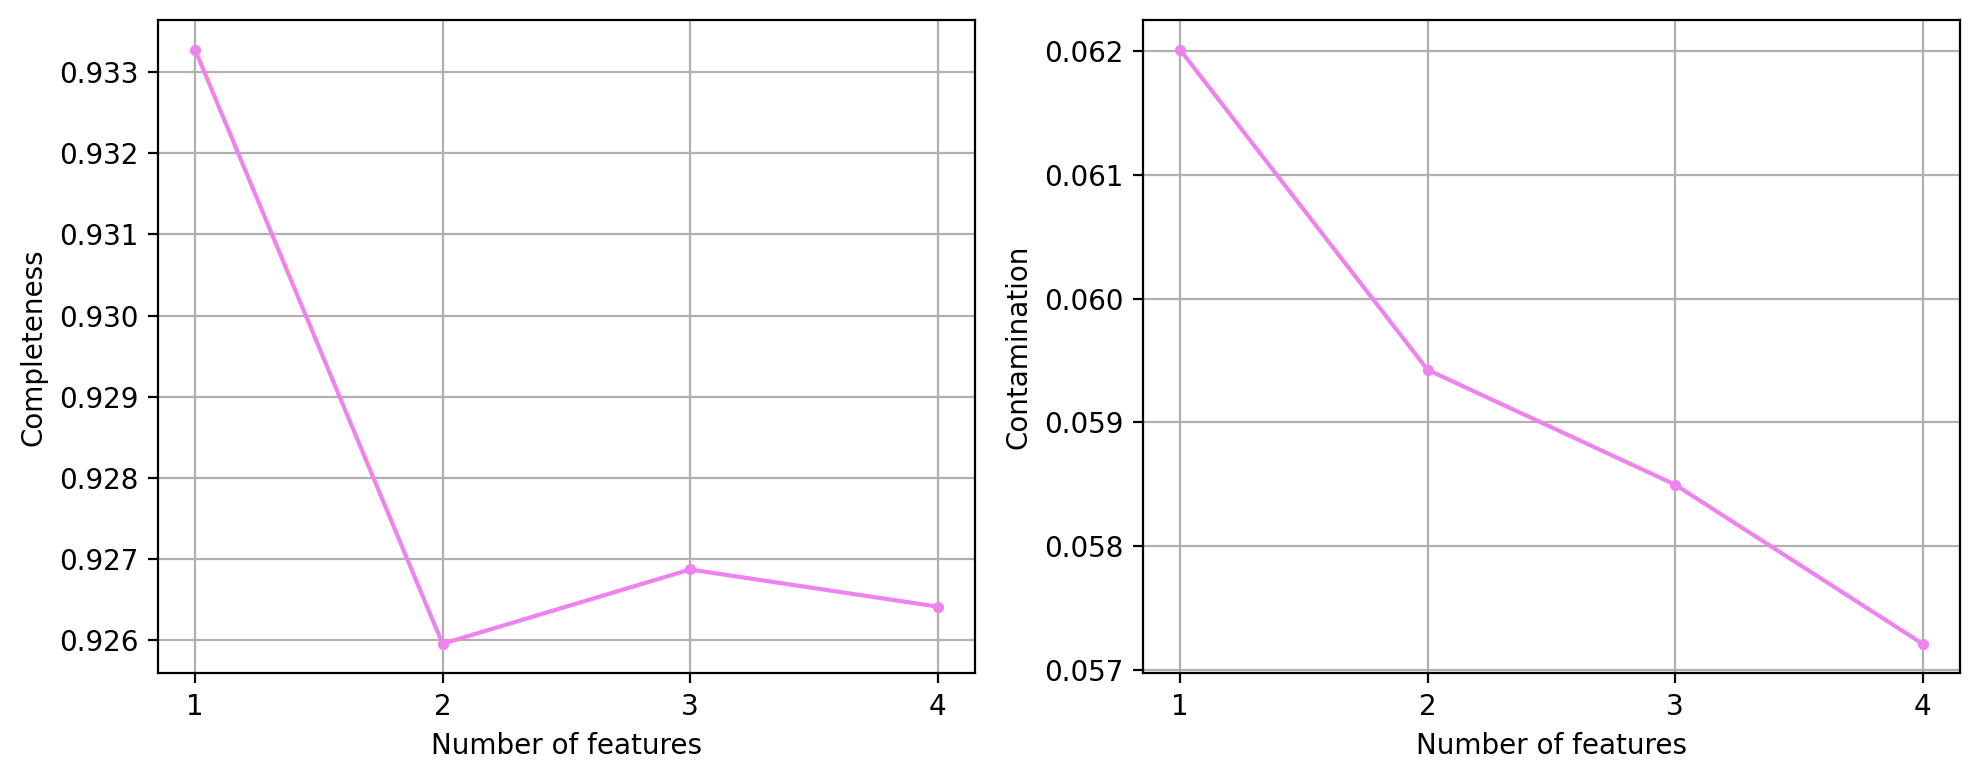

In [78]:
feat = np.linspace(1,4,4)
lab_prob = []
lab_pred = []

for x in feat:
    
    lda = LDA()
    lda.fit(X_train[:,:int(x)], label_train)
    
    pred_labels = lda.predict(X_val[:, :int(x)])
    pred_probs = lda.predict_proba(X_val[:, :int(x)])[:, 1]
    
    lab_pred.append(pred_labels)
    lab_prob.append(pred_probs)

completeness, contamination = completeness_contamination(lab_pred, label_val)
print(f'\nCompleteness = {completeness} \nContamination = {contamination}')

# Create 2 sublpots near
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(feat, completeness, marker='.', color='violet')
axs[0].set_xlabel('Number of features')
axs[0].set_ylabel('Completeness')
axs[0].set_xticks(feat)
axs[0].grid()

axs[1].plot(feat, contamination, marker='.', color='violet')
axs[1].set_xlabel('Number of features')
axs[1].set_ylabel('Contamination')
axs[1].set_xticks(feat)
axs[1].grid()

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

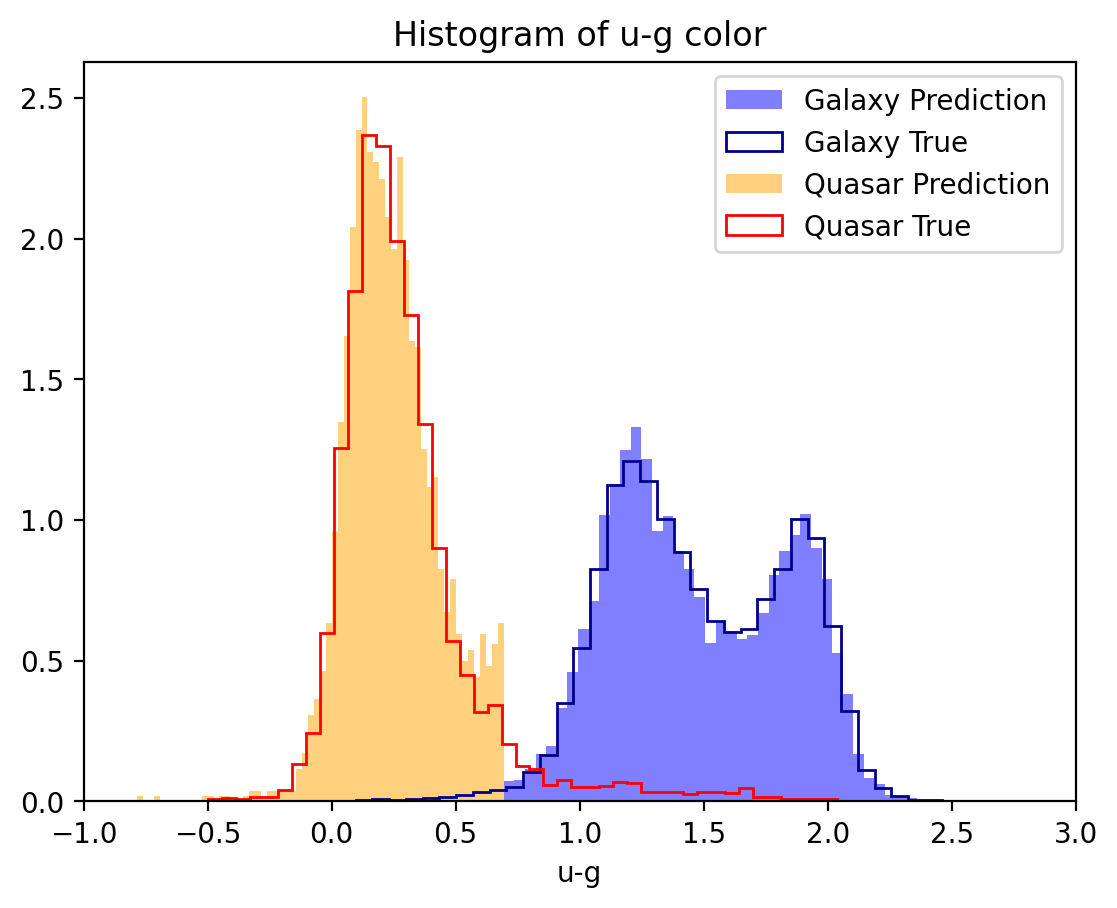

In [61]:
plt.hist( (X_val[:, 0])[ (lab_pred[0]) == 0], bins=100, density=True, alpha=0.5, color='blue', label='Galaxy Prediction')
plt.hist(v_ug[labels==0], bins=100, density=True, histtype='step', color='darkblue', label='Galaxy True')

plt.hist( (X_val[:, 0])[ (lab_pred[0]) == 1], bins=100, density=True, alpha=0.5, color='orange', label='Quasar Prediction')
plt.hist(v_ug[labels==1], bins=100, density=True, histtype='step', color='red', label='Quasar True')
#plt.hist( (X_val[:, 0])[ (lab_pred[0]) == 0], bins=100, density=True, alpha=0.7, label='Galaxy Prediction')
plt.xlim(-1,3)
plt.legend()
plt.title("Histogram of u-g color")
plt.xlabel('u-g')
plt.show

### Quadratic Discriminant Analysis

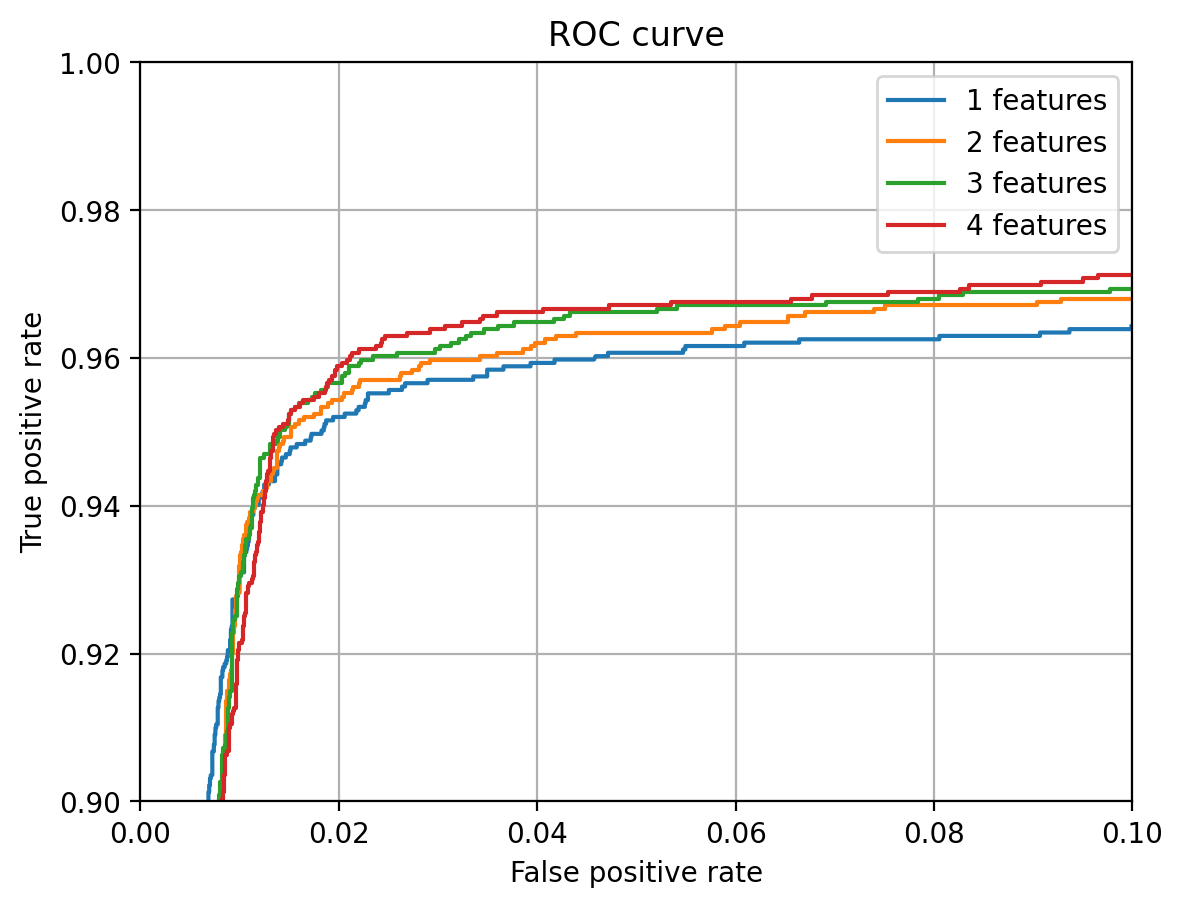

In [62]:
for i in range(4): # Every loop fit with one more component (a color)
    qda = QDA()
    qda.fit(X_train[:, 0:i+1], label_train) # Classifies if it's Galaxy or a Quasar. Every loop add a component (a color)

    # Outputing the probabilities of class 1
    label_prob = qda.predict_proba(X_val[:, 0:i+1]) [:, 1]
    
    # ROC curve
    fpr, tpr, thresh = roc_curve(label_val, label_prob)
    plt.plot(fpr, tpr, label=f"{(i+1)} features")

plt.xlim(0,0.1)
plt.ylim(0.9, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.grid()
plt.title("ROC curve")
plt.legend()


Completeness = [0.9309872  0.93418647 0.92550274 0.92276051] 
Contamination = [0.0591224  0.06022989 0.05813953 0.06180297]


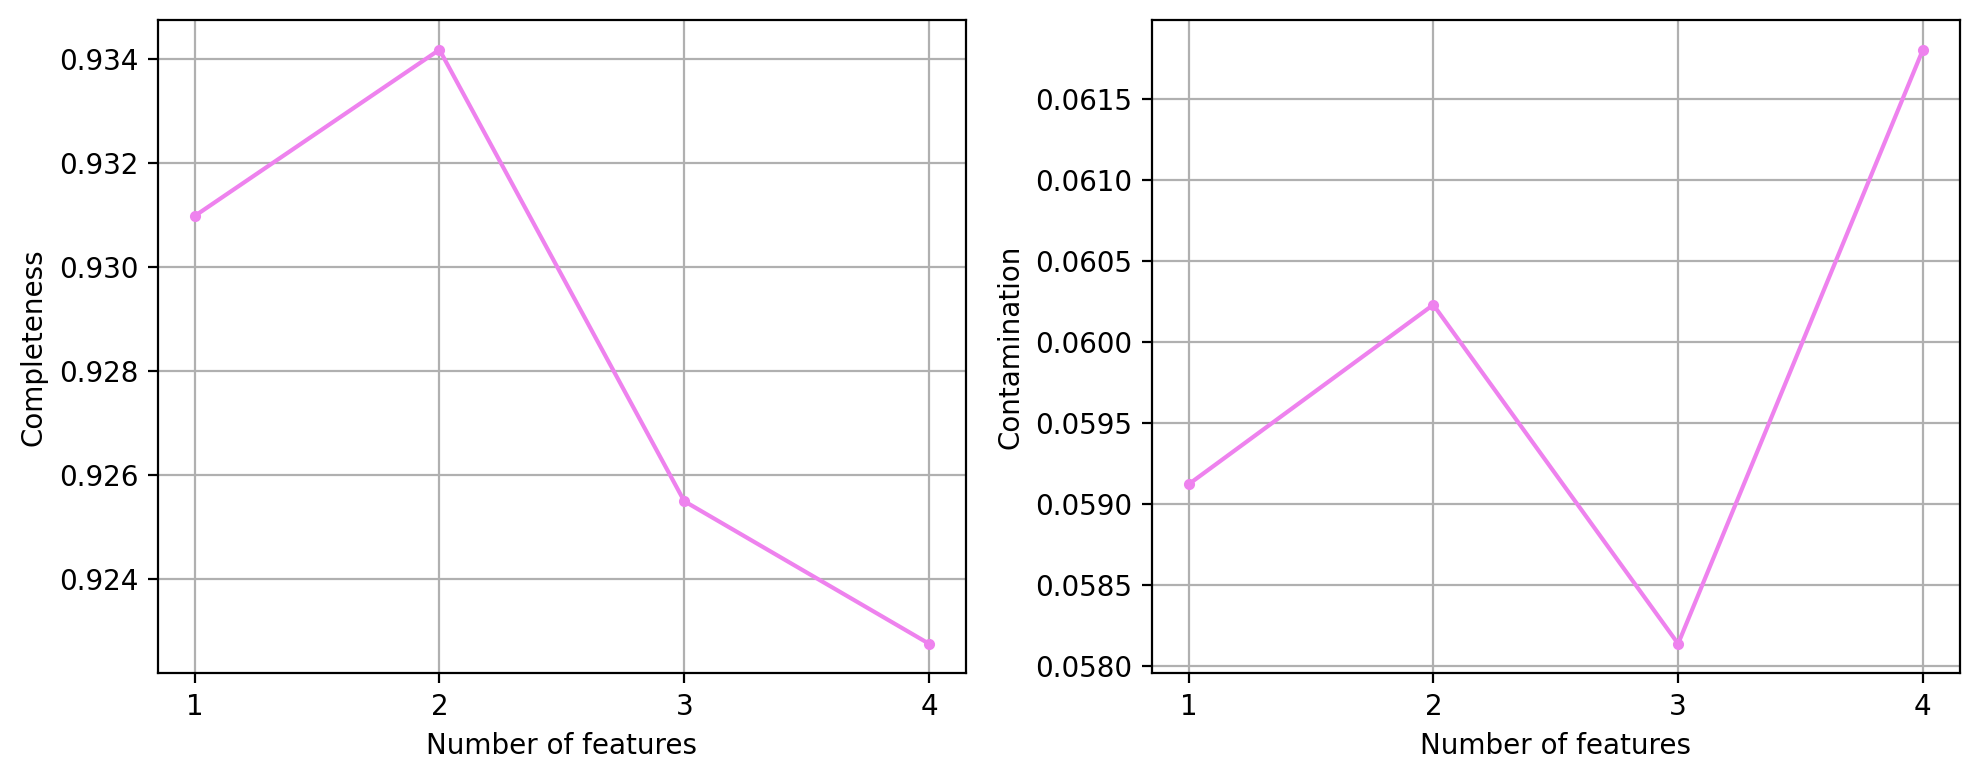

In [79]:
feat = np.linspace(1,4,4)
lab_prob = []
lab_pred = []

for x in feat:
    
    qda = QDA()
    qda.fit(X_train[:,:int(x)], label_train)
    
    pred_labels = qda.predict(X_val[:, :int(x)])
    pred_probs = qda.predict_proba(X_val[:, :int(x)])[:, 1]
    
    lab_pred.append(pred_labels)
    lab_prob.append(pred_probs)

completeness, contamination = completeness_contamination(lab_pred, label_val)
print(f'\nCompleteness = {completeness} \nContamination = {contamination}')

# Create 2 sublpots near
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(feat, completeness, marker='.', color='violet')
axs[0].set_xlabel('Number of features')
axs[0].set_ylabel('Completeness')
axs[0].set_xticks(feat)
axs[0].grid()

axs[1].plot(feat, contamination, marker='.', color='violet')
axs[1].set_xlabel('Number of features')
axs[1].set_ylabel('Contamination')
axs[1].set_xticks(feat)
axs[1].grid()

plt.tight_layout()
plt.show()

### GMM Bayes

I change only n° of Gaussian components: Instead n° of features is constant

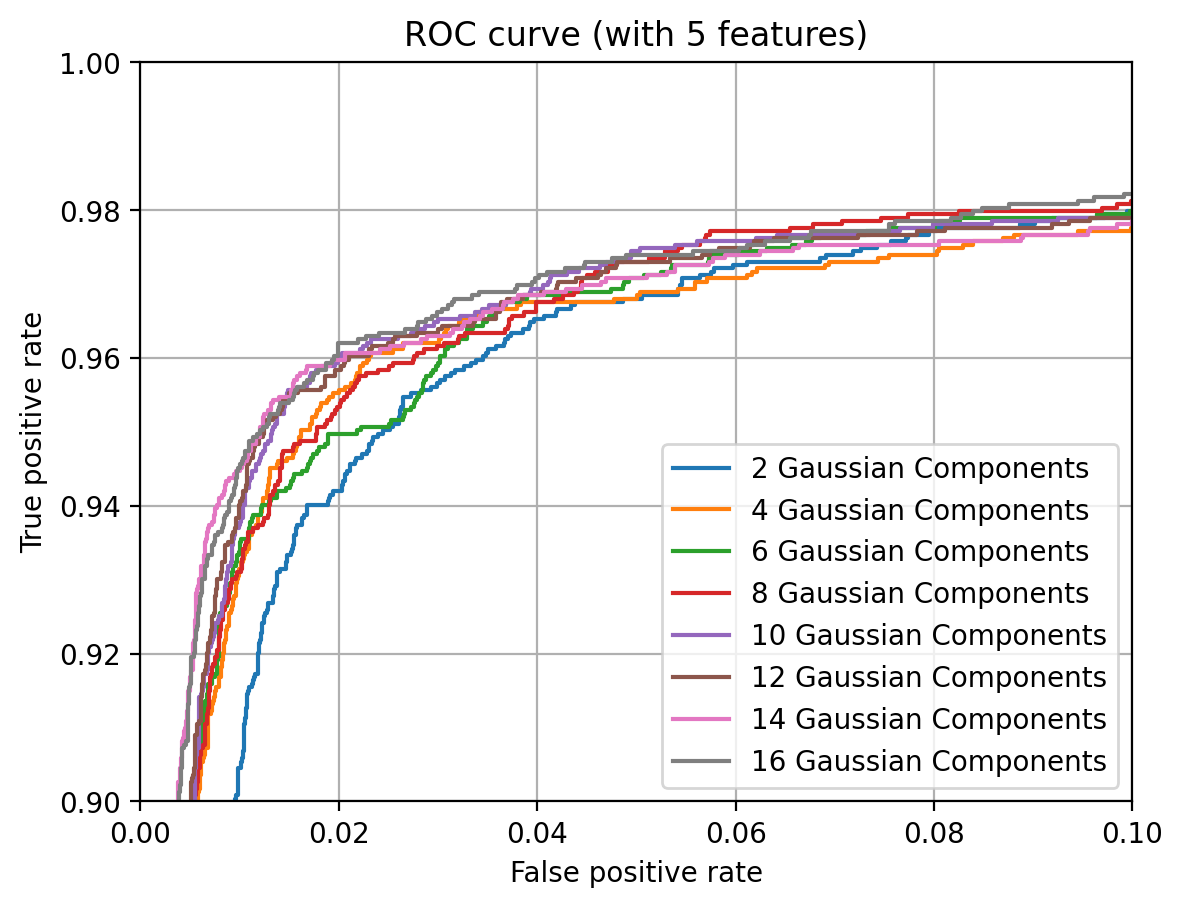

In [77]:
N = [2, 4, 6, 8, 10, 12, 14, 16]

for n in N: # Every loop fit with one Gaussian Compennts
    gmmb = GMMBayes(n)
    gmmb.fit(X_train[:, 0:4], label_train) # Classifies if it's Galaxy or a Quasar. Every loop add a component (a color)

    # Outputing the probabilities of class 1
    label_prob = gmmb.predict_proba(X_val[:, 0:4]) [:, 1] # Fit with all 4 gaussian components
    
    # ROC curve
    fpr, tpr, thresh = roc_curve(label_val, label_prob)
    plt.plot(fpr, tpr, label=f"{(n)} Gaussian Components")

plt.xlim(0,0.1)
plt.ylim(0.9, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.grid()
plt.title("ROC curve (with 5 features)")
plt.legend()


Completeness = [0.93372943 0.92641682 0.92184644 0.93418647 0.92824497 0.93053016
 0.94012797 0.9428702 ] 
Contamination = [0.15087282 0.05852299 0.05037665 0.04930233 0.04781997 0.04502814
 0.04591837 0.04357904]


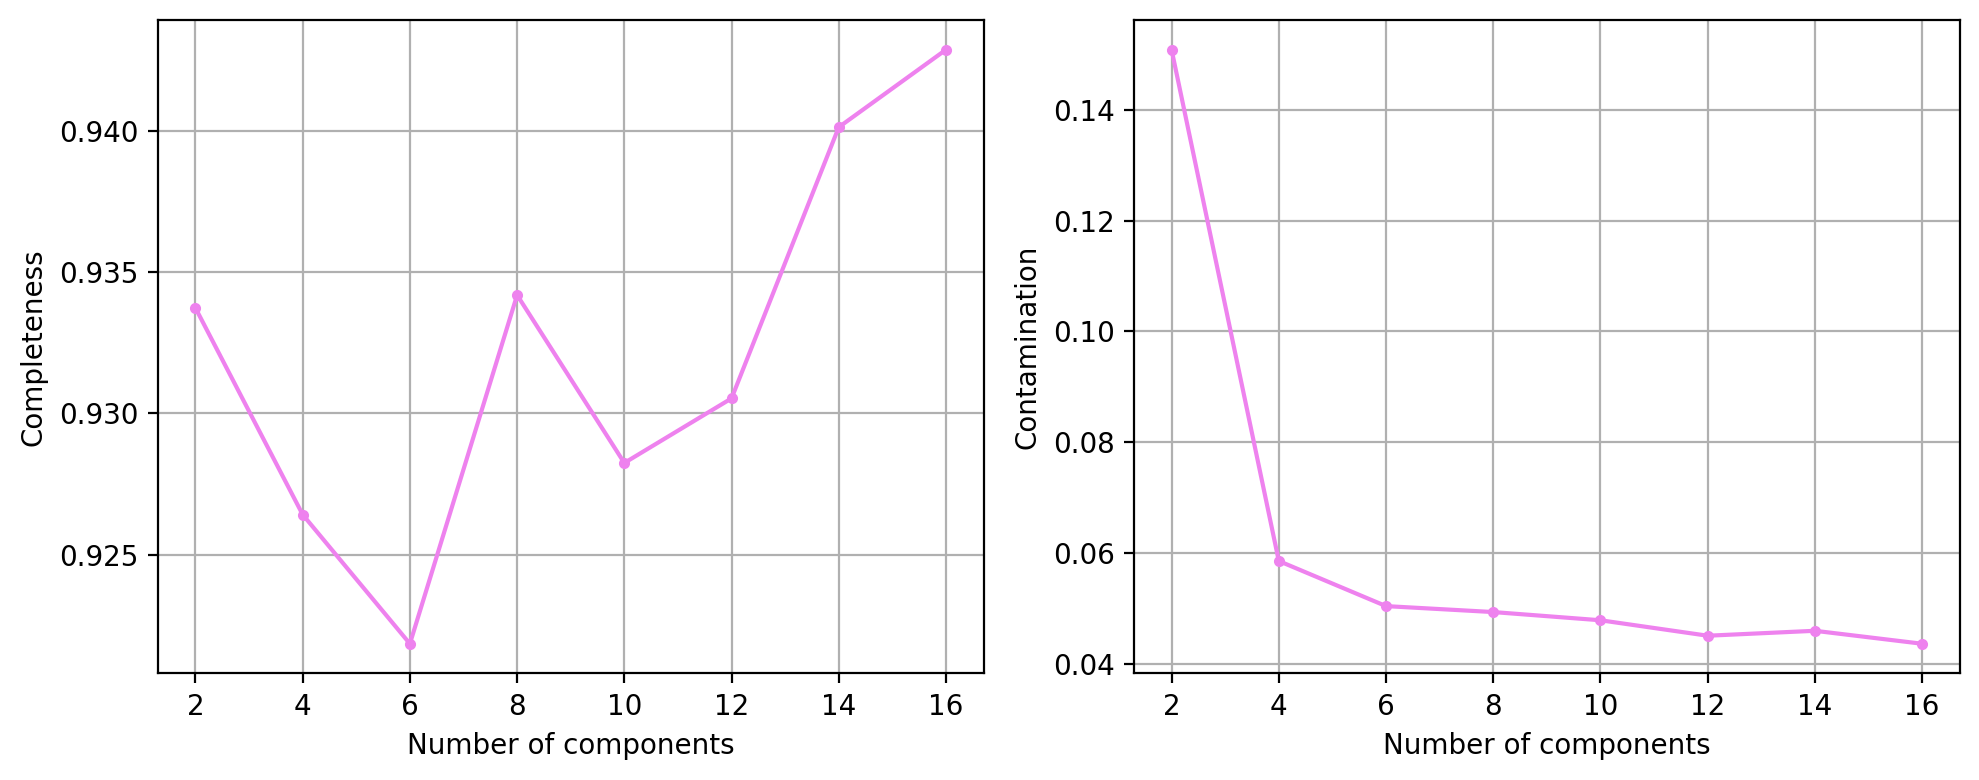

In [87]:
components = [2, 4, 6, 8, 10, 12, 14, 16]
lab_prob = []
lab_pred = []

for n in components:
    
    gmmb = GMMBayes(n)
    gmmb.fit(X_train[:, 0:4], label_train) # use all 4 features
    
    pred_labels = gmmb.predict(X_val[:, 0:4])
    pred_probs = gmmb.predict_proba(X_val[:, 0:4])[:, 1]
    
    lab_pred.append(pred_labels)
    lab_prob.append(pred_probs)

completeness, contamination = completeness_contamination(lab_pred, label_val)
print(f'\nCompleteness = {completeness} \nContamination = {contamination}')

# Create 2 sublpots near
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(components, completeness, marker='.', color='violet')
axs[0].set_xlabel('Number of components')
axs[0].set_ylabel('Completeness')
axs[0].set_xticks(components)
axs[0].grid()

axs[1].plot(components, contamination, marker='.', color='violet')
axs[1].set_xlabel('Number of components')
axs[1].set_ylabel('Contamination')
axs[1].set_xticks(components)
axs[1].grid()

plt.tight_layout()
plt.show()

GMM with 1 component 
Completeness = [0.9309872  0.93418647 0.92550274 0.92276051] 
Contamination = [0.0591224  0.06022989 0.05813953 0.06180297]

GMM with 5 components 
Completeness = [0.91499086 0.93921389 0.93601463 0.93144424] 
Contamination = [0.04712042 0.05777166 0.04566636 0.04453821]


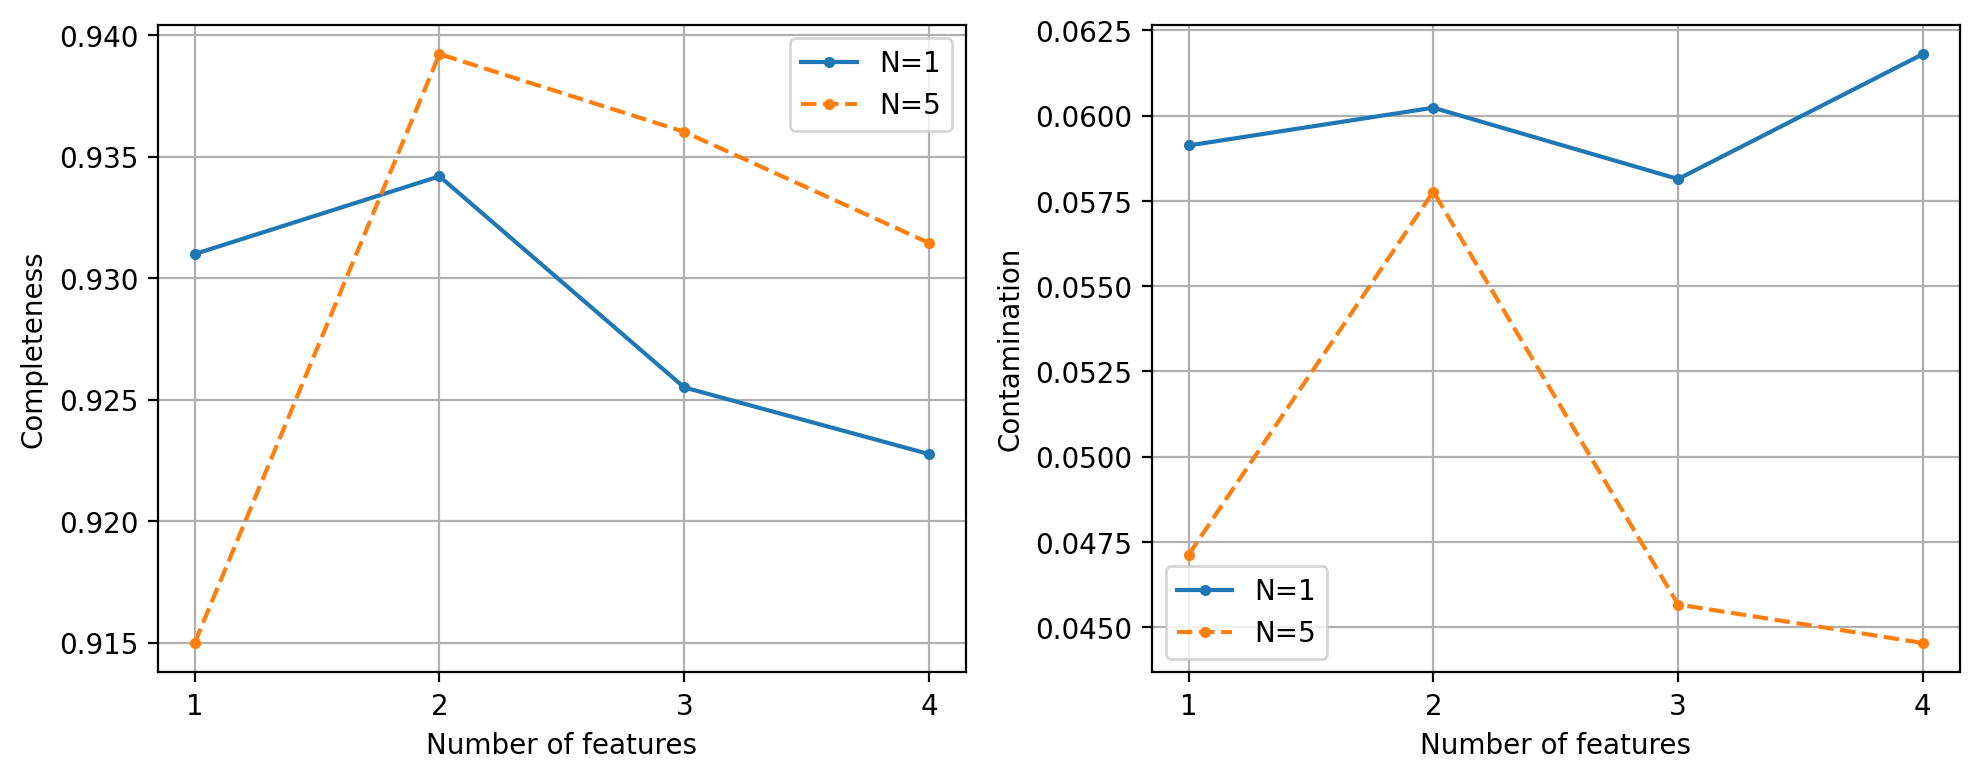

In [ ]:
lab_pred_gmm = []
lab_prob_gmm = []
clusters = [1,10]

for c in clusters:
    
    for x in feat:
        
        gmm = GMMBayes(c, covariance_type='full')
        gmm.fit(X_train[:, :int(x)], label_train)
        
        pred_labels = gmm.predict(X_val[:, :int(x)])
        pred_probs = gmm.predict_proba(X_val[:, :int(x)])[:, 1]
        
        lab_pred_gmm.append(pred_labels)
        lab_prob_gmm.append(pred_probs)



completeness, contamination = completeness_contamination(lab_pred_gmm, label_val)
print(f'GMM with 1 component \nCompleteness = {completeness[:4]} \nContamination = {contamination[:4]}\n')
print(f'GMM with 5 components \nCompleteness = {completeness[4:]} \nContamination = {contamination[4:]}')


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Completeness
axs[0].plot(feat, completeness[:4], marker='.', label='N=1')
axs[0].plot(feat, completeness[4:], marker='.', linestyle='--', label='N=5')
axs[0].set_xlabel('Number of features')
axs[0].set_ylabel('Completeness')
axs[0].grid()
axs[0].legend()
axs[0].set_xticks(feat)

# Contamination
axs[1].plot(feat, contamination[:4], marker='.', label='N=1')
axs[1].plot(feat, contamination[4:], marker='.', linestyle='--', label='N=5')
axs[1].set_xlabel('Number of features')
axs[1].set_ylabel('Contamination')
axs[1].grid()
axs[1].legend()
axs[1].set_xticks(feat)

plt.tight_layout()
plt.show()

### K-Nearest Neighbor Classifier

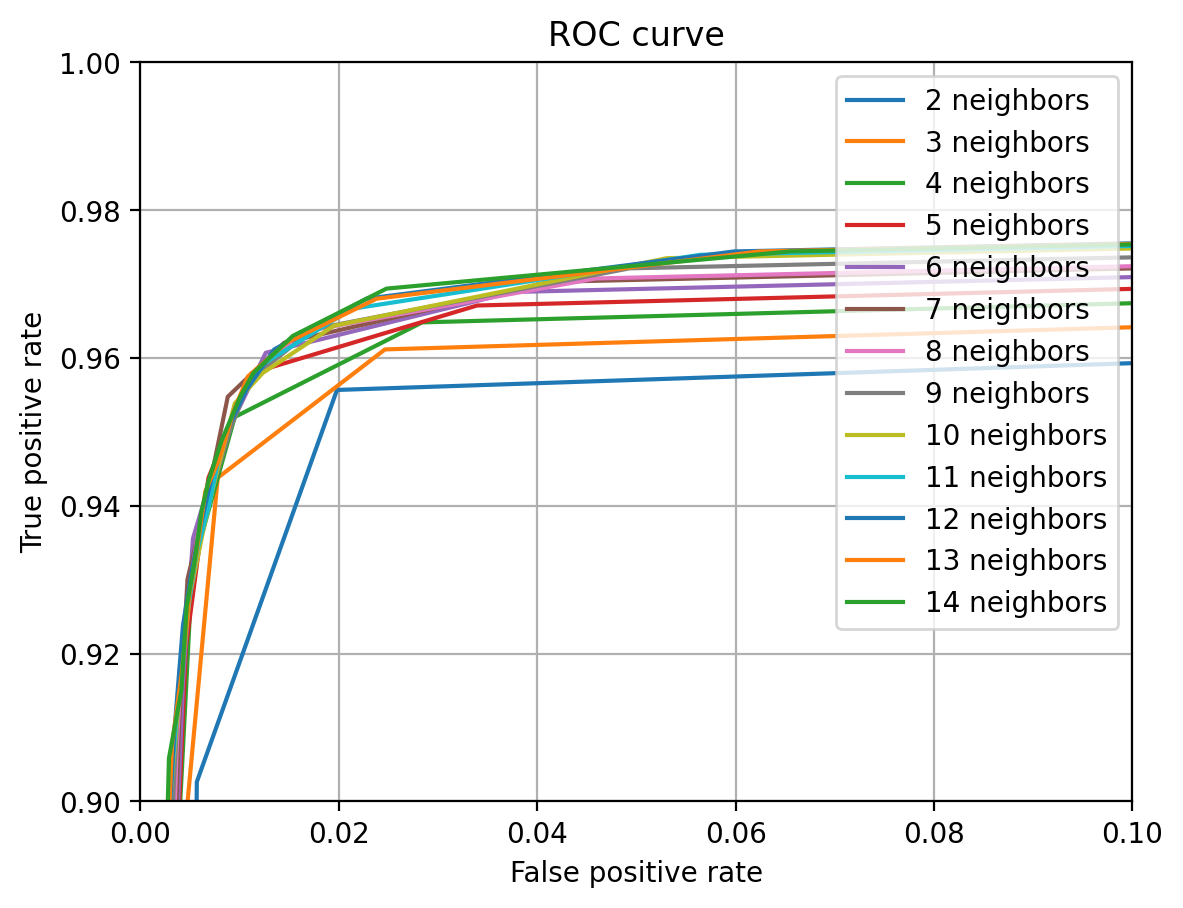

In [95]:
for i in np.arange(2, 15): # Every loop fit with one more component (a color)
    knc = KNeighborsClassifier(i)
    knc.fit(X_train[:, 0:4], label_train) # Classifies if it's Galaxy or a Quasar. Every loop add a component (a color)

    # Outputing the probabilities of class 1
    label_prob = knc.predict_proba(X_val[:, 0:4]) [:, 1]
    
    # ROC curve
    fpr, tpr, thresh = roc_curve(label_val, label_prob)
    plt.plot(fpr, tpr, label=f"{(i)} neighbors")

plt.xlim(0,0.1)
plt.ylim(0.9, 1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.grid()
plt.title("ROC curve")
plt.legend()

GMM with 1 component 
Completeness = [0.85146252 0.86517367 0.88939671 0.90265082] 
Contamination = [0.05094244 0.04151899 0.03948667 0.03564453]

GMM with 5 components 
Completeness = [0.91956124 0.92093236 0.93784278 0.93601463] 
Contamination = [0.05139085 0.04773157 0.04201681 0.03759398]


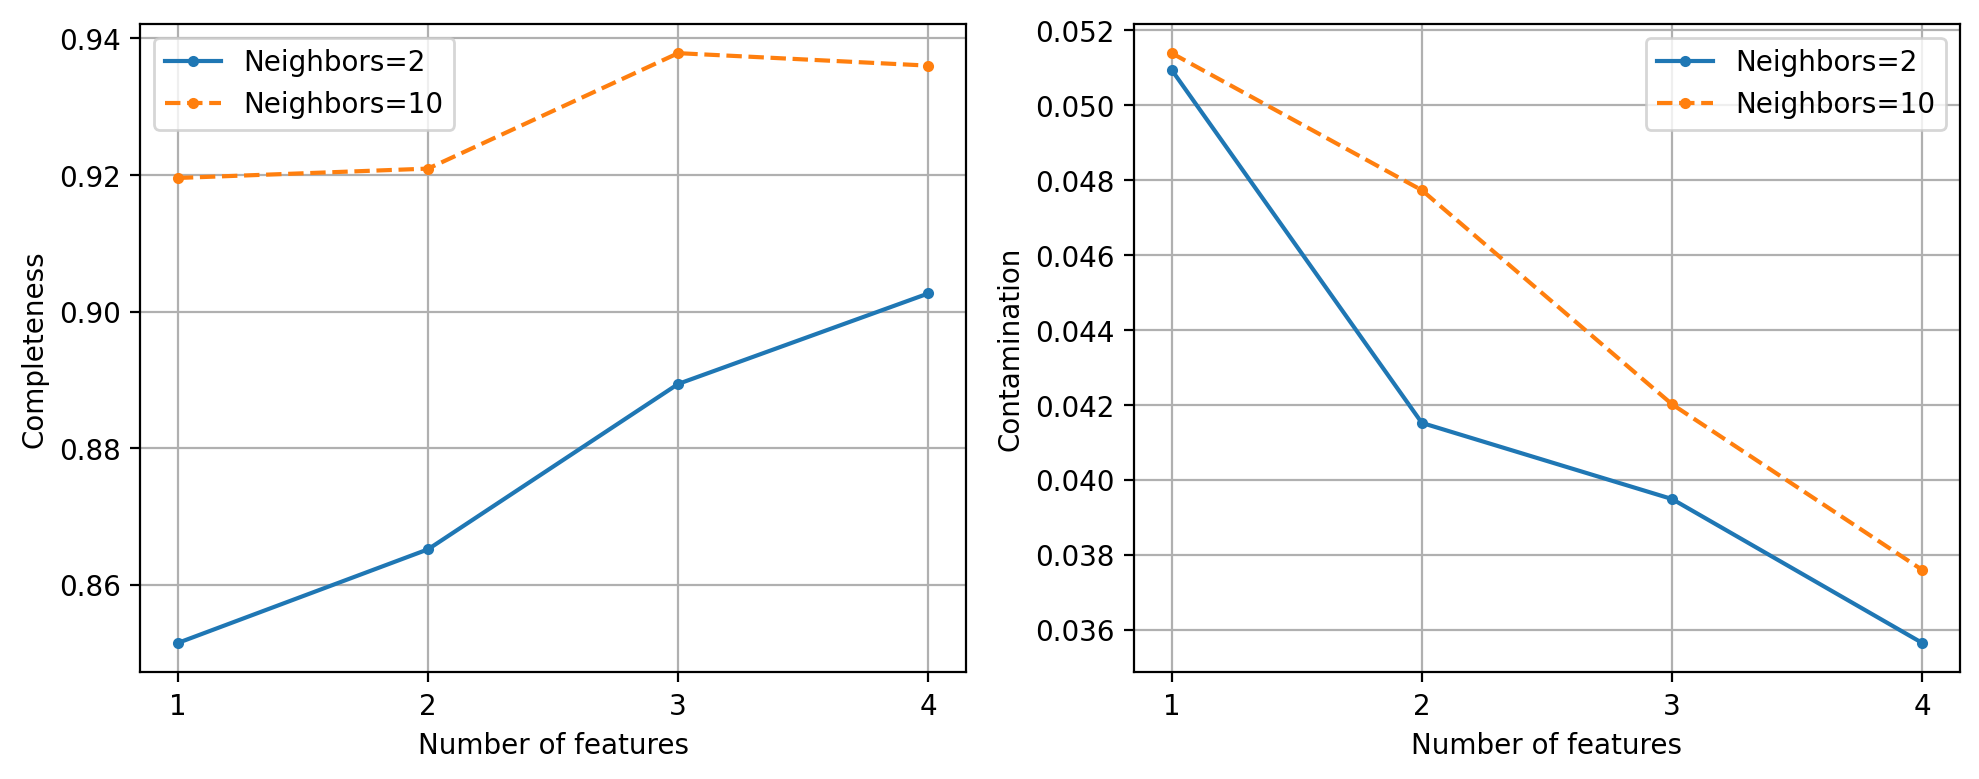

In [100]:
lab_pred_gmm = []
lab_prob_gmm = []
neighbors = [2,10]

for n in neighbors:
    
    for x in feat:
        
        knc = KNeighborsClassifier(n)
        knc.fit(X_train[:, :int(x)], label_train) # Classifies if it's Galaxy or a Quasar. Every loop add a component (a color)

        pred_labels = knc.predict(X_val[:, :int(x)])
        pred_probs = knc.predict_proba(X_val[:, :int(x)])[:, 1]
        
        lab_pred_gmm.append(pred_labels)
        lab_prob_gmm.append(pred_probs)



completeness, contamination = completeness_contamination(lab_pred_gmm, label_val)
print(f'GMM with 1 component \nCompleteness = {completeness[:4]} \nContamination = {contamination[:4]}\n')
print(f'GMM with 5 components \nCompleteness = {completeness[4:]} \nContamination = {contamination[4:]}')


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Completeness
axs[0].plot(feat, completeness[:4], marker='.', label='Neighbors=2')
axs[0].plot(feat, completeness[4:], marker='.', linestyle='--', label='Neighbors=10')
axs[0].set_xlabel('Number of features')
axs[0].set_ylabel('Completeness')
axs[0].grid()
axs[0].legend()
axs[0].set_xticks(feat)

# Contamination
axs[1].plot(feat, contamination[:4], marker='.', label='Neighbors=2')
axs[1].plot(feat, contamination[4:], marker='.', linestyle='--', label='Neighbors=10')
axs[1].set_xlabel('Number of features')
axs[1].set_ylabel('Contamination')
axs[1].grid()
axs[1].legend()
axs[1].set_xticks(feat)

plt.tight_layout()
plt.show()

[My exploration](https://github.com/dgerosa/astrostatistics_bicocca_2025/blob/main/solutions/S19_galaxyquasar1.ipynb)